Importing what I need

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost

Importing the dataset and checking if it works

In [2]:
df = pd.read_csv(
    r"C:\Users\kavya\Downloads\synthetic_health_data.csv"
)

df.head()

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
0,45.960570,31.996777,5,55.403270,7.300359,0,2.834707,70.542122
1,38.340828,29.623168,6,41.838357,7.012419,1,7.199517,57.244637
2,47.772262,25.298152,5,76.904948,6.028641,1,4.097944,96.333722
3,58.276358,21.765316,2,49.756767,5.802714,1,3.649377,61.321783
4,37.190160,28.491117,2,44.218737,7.912548,0,2.839795,67.175894


Checking different values such as the size of the dataset, the names of the columns, the type of value for each column, and if there are any missing values or duplicate rows.

In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (1000, 8)

Column names:
['Age', 'BMI', 'Exercise_Frequency', 'Diet_Quality', 'Sleep_Hours', 'Smoking_Status', 'Alcohol_Consumption', 'Health_Score']

Data types:
Age                    float64
BMI                    float64
Exercise_Frequency       int64
Diet_Quality           float64
Sleep_Hours            float64
Smoking_Status           int64
Alcohol_Consumption    float64
Health_Score           float64
dtype: object

Missing values:
Age                    0
BMI                    0
Exercise_Frequency     0
Diet_Quality           0
Sleep_Hours            0
Smoking_Status         0
Alcohol_Consumption    0
Health_Score           0
dtype: int64

Duplicate rows:
0


Getting the statistics to find any invalid values

In [4]:
df.describe()

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.231985,25.354181,2.888000,69.952977,6.973135,0.499000,3.079377,85.479947
std,11.750591,4.987272,1.995354,14.972061,1.517218,0.500249,2.084564,13.633845
min,1.104792,10.298057,0.000000,19.907497,2.431107,0.000000,-3.592506,29.106017
25%,32.228916,21.968792,1.000000,59.945481,5.903351,0.000000,1.644111,76.430819
50%,40.303607,25.315386,3.000000,69.975151,6.990847,0.000000,3.064261,87.498996
75%,47.775327,28.644411,5.000000,80.527839,8.054595,1.000000,4.489293,99.762644
max,86.232778,40.965538,6.000000,110.265186,11.638962,1.000000,11.105100,100.000000


Shown above, a minimum age below 18 years old will probably be invalid, a maximum diet quality of 110 is wrong as the index goes to 100, and alcohol consumption can't be negative

Finding suspicious rows

In [5]:
print("Ages below 18:")
print(df[df["Age"] < 18][["Age", "BMI", "Exercise_Frequency", "Diet_Quality", "Sleep_Hours", "Health_Score"]])

print("\nDiet scores above 100:")
print(df[df["Diet_Quality"] > 100][["Age", "Diet_Quality", "Health_Score"]])

print("\nNegative alcohol consumption:")
print(df[df["Alcohol_Consumption"] < 0][["Age", "Alcohol_Consumption", "Health_Score"]])

Ages below 18:
           Age        BMI  Exercise_Frequency  Diet_Quality  Sleep_Hours  \
13   17.040637  21.554061                   2     32.671566     6.881407   
37   16.483959  17.678126                   6     69.541448     6.001819   
74    8.563059  29.981334                   4     58.494737     5.340071   
79   16.149173  29.251109                   3     76.160960     4.495300   
110  16.974745  24.046588                   5     64.617304     7.663119   
221  17.592818  26.549104                   3     77.449971     5.813278   
236  15.698289  33.388504                   1     49.632663     6.445454   
262   1.104792  27.693780                   1     66.930674     7.193401   
285  16.574946  18.343835                   4     69.070709     5.768663   
382  14.513251  35.786541                   1     76.508213     8.202271   
431  15.529214  29.078686                   2     56.917695     5.689647   
442  15.190695  25.905108                   5     58.339149     7.685451 

In [6]:
print("Diet Quality > 100:", (df["Diet_Quality"] > 100).sum())
print("Alcohol < 0:", (df["Alcohol_Consumption"] < 0).sum())
print("Age < 18:", (df["Age"] < 18).sum())

Diet Quality > 100: 18
Alcohol < 0: 70
Age < 18: 26


Gather more information

In [7]:
print(df["Smoking_Status"].value_counts().sort_index())
print(df["Exercise_Frequency"].value_counts().sort_index())

Smoking_Status
0    501
1    499
Name: count, dtype: int64
Exercise_Frequency
0    161
1    139
2    147
3    149
4    141
5    134
6    129
Name: count, dtype: int64


In [8]:
print("Diet Quality > 100:")
print(df.loc[df["Diet_Quality"] > 100, "Diet_Quality"].describe())

print("\nNegative Alcohol Consumption:")
print(df.loc[df["Alcohol_Consumption"] < 0, "Alcohol_Consumption"].describe())

Diet Quality > 100:
count     18.000000
mean     104.103000
std        3.060623
min      100.354009
25%      101.595728
50%      103.409704
75%      106.438721
max      110.265186
Name: Diet_Quality, dtype: float64

Negative Alcohol Consumption:
count    70.000000
mean     -0.882462
std       0.748911
min      -3.592506
25%      -0.973180
50%      -0.768122
75%      -0.422314
max      -0.023396
Name: Alcohol_Consumption, dtype: float64


In [9]:
print("Diet Quality range:")
print(df["Diet_Quality"].min(), "to", df["Diet_Quality"].max())

print("\nAlcohol Consumption range:")
print(df["Alcohol_Consumption"].min(), "to", df["Alcohol_Consumption"].max())

Diet Quality range:
19.90749732618637 to 110.26518613634968

Alcohol Consumption range:
-3.5925060239650595 to 11.105100244423912


Begin cleaning on alcohol_consumption

In [10]:
df_clean = df.copy()


df_clean["Invalid_Alcohol"] = df_clean["Alcohol_Consumption"] < 0
df_clean["Invalid_Diet"] = df_clean["Diet_Quality"] > 100

print("Invalid alcohol values:", df_clean["Invalid_Alcohol"].sum())
print("Potentially invalid diet values:", df_clean["Invalid_Diet"].sum())

Invalid alcohol values: 70
Potentially invalid diet values: 18


Remove invalid values

In [11]:
df_clean.loc[
    df_clean["Alcohol_Consumption"] < 0,
    "Alcohol_Consumption"
] = np.nan

In [12]:
print(df_clean["Alcohol_Consumption"].isnull().sum())

70


Replace invalid values with an estimated value

In [13]:
alcohol_median = df_clean["Alcohol_Consumption"].median()

df_clean["Alcohol_Consumption"] = df_clean["Alcohol_Consumption"].fillna(
    alcohol_median
)

print("Median alcohol consumption used:", alcohol_median)
print("Missing alcohol values remaining:",
      df_clean["Alcohol_Consumption"].isnull().sum())

Median alcohol consumption used: 3.26350435464424
Missing alcohol values remaining: 0


Investigate health_score and correlations:

In [14]:
print("Health Score = 100:")
print((df_clean["Health_Score"] == 100).sum())

print("\nHealth Score statistics:")
print(df_clean["Health_Score"].describe())

Health Score = 100:
242

Health Score statistics:
count    1000.000000
mean       85.479947
std        13.633845
min        29.106017
25%        76.430819
50%        87.498996
75%        99.762644
max       100.000000
Name: Health_Score, dtype: float64


In [15]:
print(
    df_clean.loc[
        df_clean["Invalid_Diet"],
        ["Diet_Quality", "Health_Score"]
    ].sort_values("Diet_Quality")
)

     Diet_Quality  Health_Score
432    100.354009    100.000000
437    100.387106    100.000000
399    100.525491    100.000000
204    101.160700    100.000000
751    101.555979     93.418247
748    101.714976    100.000000
655    102.735348    100.000000
212    102.820851    100.000000
907    103.275152    100.000000
299    103.544255    100.000000
407    104.007703    100.000000
606    104.999340    100.000000
688    106.437165    100.000000
757    106.439240    100.000000
406    107.190841    100.000000
473    108.002742    100.000000
319    108.437915    100.000000
865    110.265186    100.000000


In [16]:
correlations = (
    df_clean
    .corr(numeric_only=True)["Health_Score"]
    .sort_values(ascending=False)
)

print(correlations)

Health_Score           1.000000
Diet_Quality           0.680686
Sleep_Hours            0.269033
Exercise_Frequency     0.245036
Invalid_Diet           0.140628
Invalid_Alcohol        0.096253
Alcohol_Consumption   -0.100612
Smoking_Status        -0.109123
Age                   -0.186939
BMI                   -0.415147
Name: Health_Score, dtype: float64


Visualization

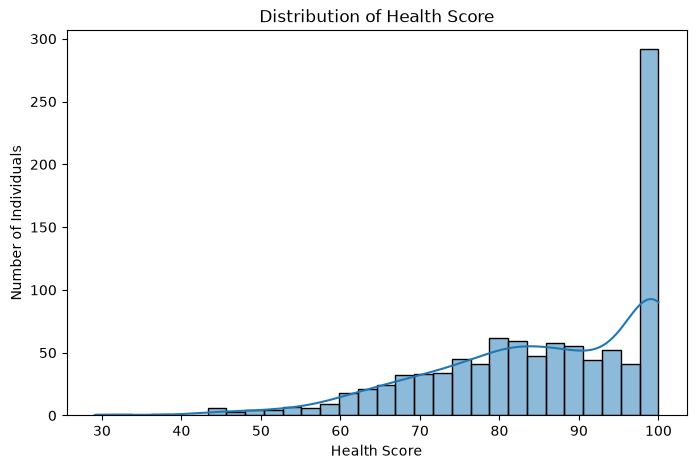

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Health_Score"], bins=30, kde=True)
plt.title("Distribution of Health Score")
plt.xlabel("Health Score")
plt.ylabel("Number of Individuals")
plt.show()

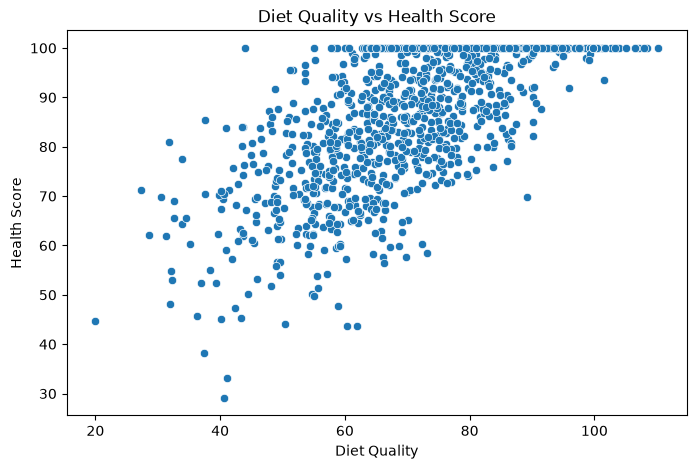

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="Diet_Quality",
    y="Health_Score"
)
plt.title("Diet Quality vs Health Score")
plt.xlabel("Diet Quality")
plt.ylabel("Health Score")
plt.show()

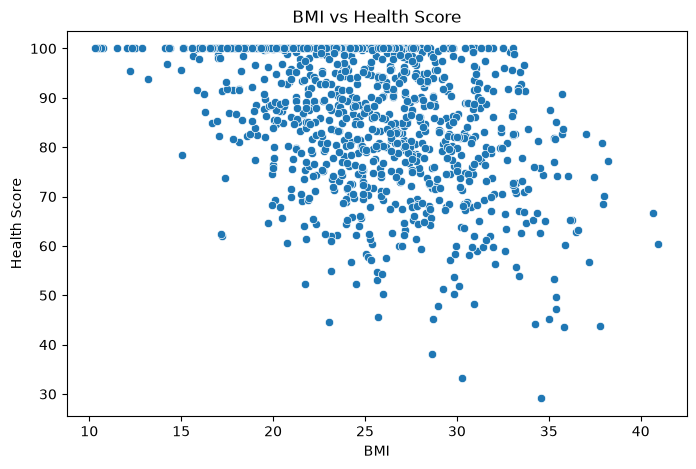

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="BMI",
    y="Health_Score"
)
plt.title("BMI vs Health Score")
plt.xlabel("BMI")
plt.ylabel("Health Score")
plt.show()

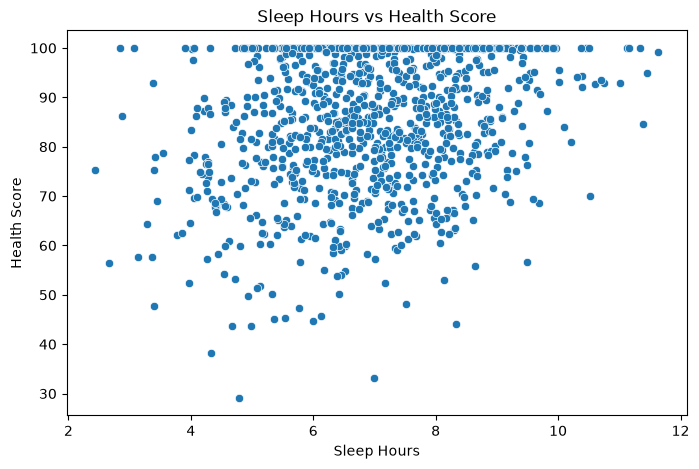

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="Sleep_Hours",
    y="Health_Score"
)
plt.title("Sleep Hours vs Health Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Health Score")
plt.show()

Distribution is not normal, an unusually high amount of 100 health scores

Comparing health scores across smoking status and exercise frequency:

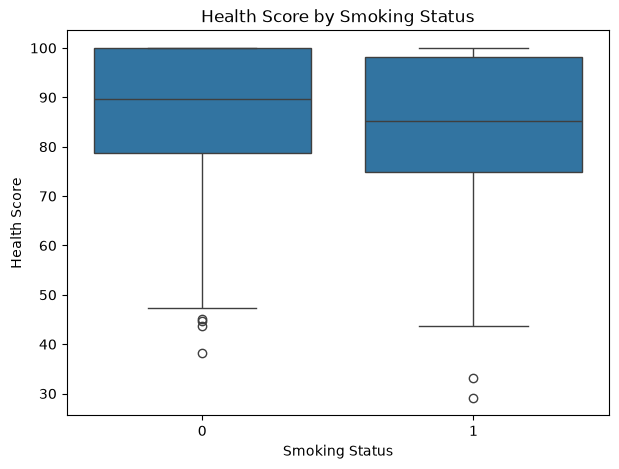

In [21]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="Smoking_Status",
    y="Health_Score"
)

plt.title("Health Score by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Health Score")

plt.show()

In [22]:
print(
    df_clean.groupby("Smoking_Status")["Health_Score"]
    .agg(["count", "mean", "median", "std"])
)

                count       mean     median        std
Smoking_Status                                        
0                 501  86.963995  89.568797  13.028084
1                 499  83.989952  85.306029  14.072327


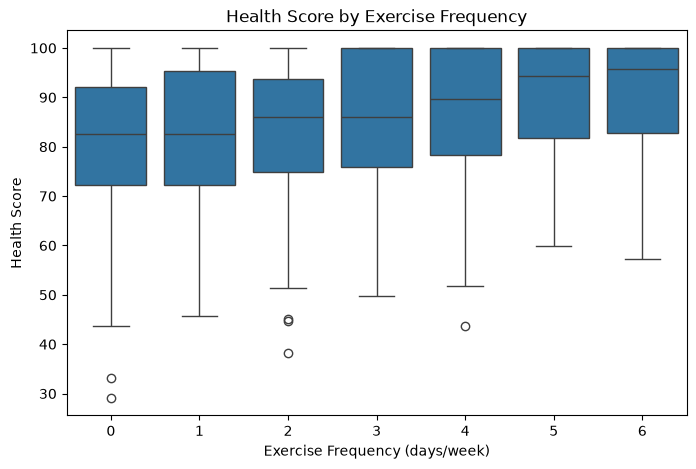

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Exercise_Frequency",
    y="Health_Score"
)

plt.title("Health Score by Exercise Frequency")
plt.xlabel("Exercise Frequency (days/week)")
plt.ylabel("Health Score")

plt.show()

In [24]:
print(
    df_clean.groupby("Exercise_Frequency")["Health_Score"]
    .agg(["count", "mean", "median", "std"])
)

                    count       mean     median        std
Exercise_Frequency                                        
0                     161  80.843052  82.531389  15.024581
1                     139  82.588252  82.493775  13.804950
2                     147  83.268349  86.071235  14.205544
3                     149  85.867147  86.084193  12.980980
4                     141  87.122470  89.568797  12.485057
5                     134  89.164516  94.247425  12.302520
6                     129  90.833206  95.793878  11.061854


Health score clearly increases with people who smoke less and exercise more. However, it is less variable among people who exercise more frequently

Outliers and skewed features:

In [25]:
numeric_columns = [
    "Age",
    "BMI",
    "Exercise_Frequency",
    "Diet_Quality",
    "Sleep_Hours",
    "Alcohol_Consumption",
    "Health_Score"
]

for column in numeric_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    print(f"\n{column}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of potential outliers: {len(outliers)}")


Age
Lower bound: 8.91
Upper bound: 71.09
Number of potential outliers: 8

BMI
Lower bound: 11.96
Upper bound: 38.66
Number of potential outliers: 8

Exercise_Frequency
Lower bound: -5.00
Upper bound: 11.00
Number of potential outliers: 0

Diet_Quality
Lower bound: 29.07
Upper bound: 111.40
Number of potential outliers: 3

Sleep_Hours
Lower bound: 2.68
Upper bound: 11.28
Number of potential outliers: 6

Alcohol_Consumption
Lower bound: -1.63
Upper bound: 8.16
Number of potential outliers: 9

Health_Score
Lower bound: 41.43
Upper bound: 134.76
Number of potential outliers: 3


The IQR method identified potential outliers in Age (8), BMI (8), Diet Quality (3), Sleep Hours (6), Alcohol Consumption (9), and Health Score (3), while Exercise Frequency had no potential outliers. These observations were retained because statistical outliers are not necessarily data errors. Invalid negative Alcohol Consumption values were handled separately during data cleaning

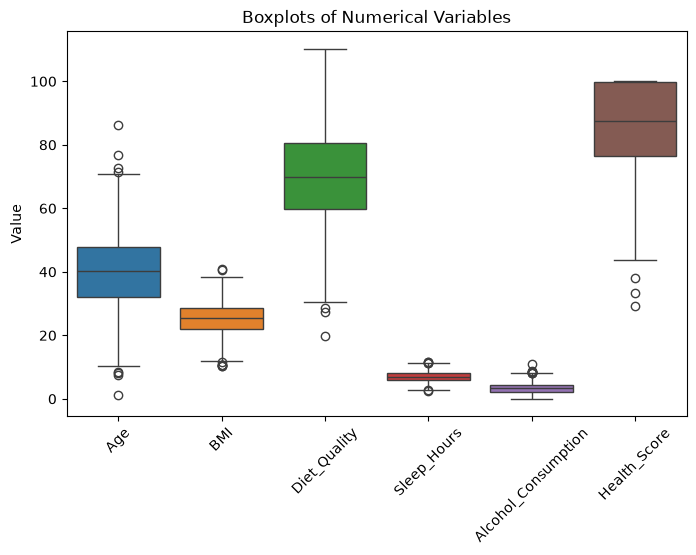

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean[
        ["Age", "BMI", "Diet_Quality", "Sleep_Hours",
         "Alcohol_Consumption", "Health_Score"]
    ]
)

plt.title("Boxplots of Numerical Variables")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

The correlation matrix

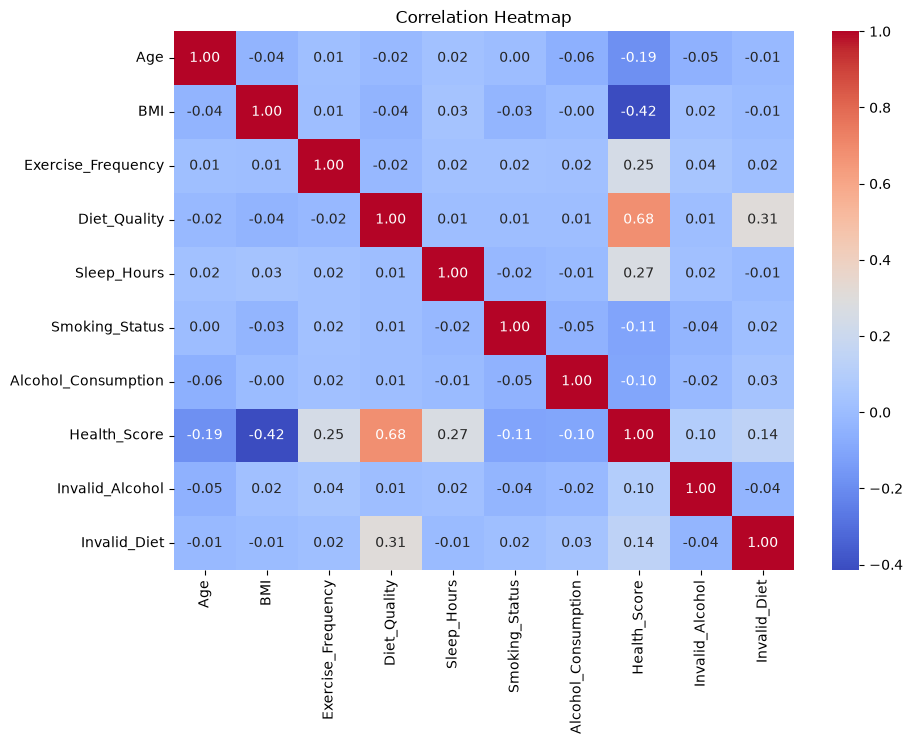

In [27]:
plt.figure(figsize=(10, 7))

correlation_matrix = df_clean.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
print(df_clean.columns)

Index(['Age', 'BMI', 'Exercise_Frequency', 'Diet_Quality', 'Sleep_Hours',
       'Smoking_Status', 'Alcohol_Consumption', 'Health_Score',
       'Invalid_Alcohol', 'Invalid_Diet'],
      dtype='str')


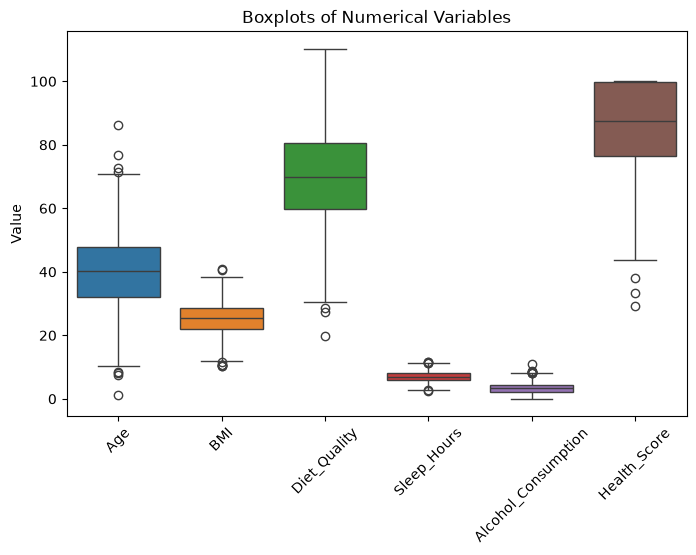

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean[
        ["Age", "BMI", "Diet_Quality", "Sleep_Hours",
         "Alcohol_Consumption", "Health_Score"]
    ]
)

plt.title("Boxplots of Numerical Variables")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

The correlation heatmap

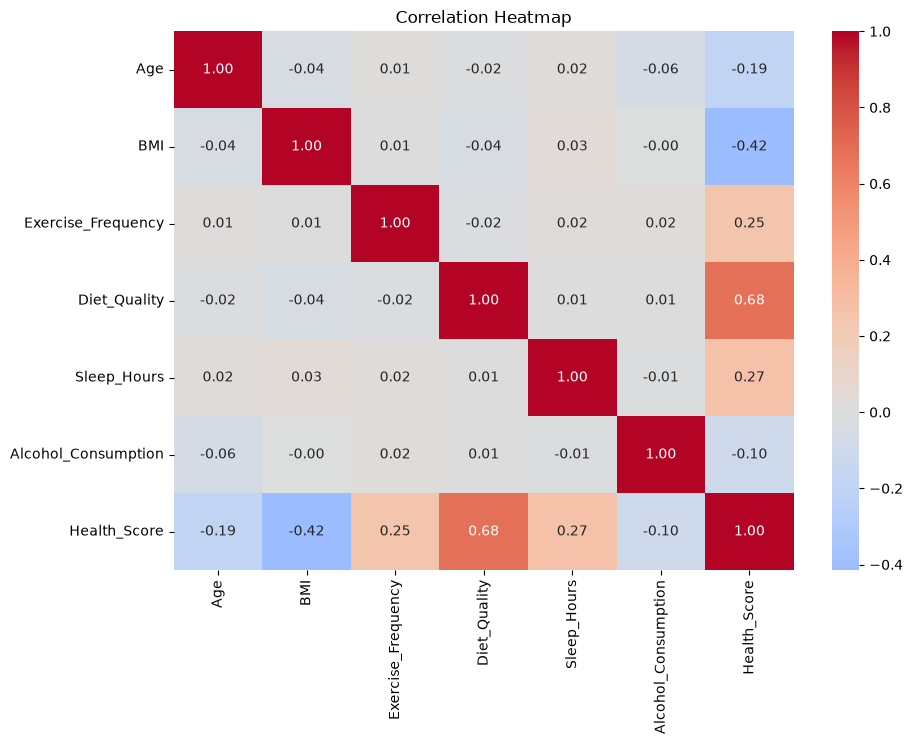

In [30]:
correlation_matrix = df_clean[
    ["Age", "BMI", "Exercise_Frequency", "Diet_Quality",
     "Sleep_Hours", "Alcohol_Consumption", "Health_Score"]
].corr()

# Display the correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [31]:
df_clean[["Invalid_Alcohol", "Invalid_Diet"]].value_counts()

Invalid_Alcohol  Invalid_Diet
False            False           912
True             False            70
False            True             18
Name: count, dtype: int64

In [32]:
df_clean[["Invalid_Alcohol", "Invalid_Diet", "Health_Score"]].corr(
    numeric_only=True
)

,Invalid_Alcohol,Invalid_Diet,Health_Score
Invalid_Alcohol,1.000000,-0.037144,0.096253
Invalid_Diet,-0.037144,1.000000,0.140628
Health_Score,0.096253,0.140628,1.000000


Cleaning check

In [33]:
df_clean[[
    "Age",
    "BMI",
    "Exercise_Frequency",
    "Diet_Quality",
    "Sleep_Hours",
    "Alcohol_Consumption",
    "Health_Score"
]].describe()

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Alcohol_Consumption,Health_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.231985,25.354181,2.888000,69.952977,6.973135,3.369594,85.479947
std,11.750591,4.987272,1.995354,14.972061,1.517218,1.767739,13.633845
min,1.104792,10.298057,0.000000,19.907497,2.431107,0.026080,29.106017
25%,32.228916,21.968792,1.000000,59.945481,5.903351,2.041408,76.430819
50%,40.303607,25.315386,3.000000,69.975151,6.990847,3.263504,87.498996
75%,47.775327,28.644411,5.000000,80.527839,8.054595,4.489293,99.762644
max,86.232778,40.965538,6.000000,110.265186,11.638962,11.105100,100.000000


In [34]:
print("Diet Quality > 100:", (df_clean["Diet_Quality"] > 100).sum())
print("Diet Quality < 0:", (df_clean["Diet_Quality"] < 0).sum())

print("\nInvalid Diet values:")
print(df_clean.loc[df_clean["Diet_Quality"] > 100, "Diet_Quality"])

Diet Quality > 100: 18
Diet Quality < 0: 0

Invalid Diet values:
204    101.160700
212    102.820851
299    103.544255
319    108.437915
399    100.525491
406    107.190841
407    104.007703
432    100.354009
437    100.387106
473    108.002742
606    104.999340
655    102.735348
688    106.437165
748    101.714976
751    101.555979
757    106.439240
865    110.265186
907    103.275152
Name: Diet_Quality, dtype: float64


In [35]:
print("Alcohol values < 0:", (df_clean["Alcohol_Consumption"] < 0).sum())

Alcohol values < 0: 0


Clean final diet quality values

In [36]:
df_clean.loc[df_clean["Invalid_Diet"], "Diet_Quality"]

204    101.160700
212    102.820851
299    103.544255
319    108.437915
399    100.525491
406    107.190841
407    104.007703
432    100.354009
437    100.387106
473    108.002742
606    104.999340
655    102.735348
688    106.437165
748    101.714976
751    101.555979
757    106.439240
865    110.265186
907    103.275152
Name: Diet_Quality, dtype: float64

In [37]:
valid_diet_median = df_clean.loc[
    ~df_clean["Invalid_Diet"], "Diet_Quality"
].median()

print("Median valid Diet Quality:", valid_diet_median)

Median valid Diet Quality: 69.62039539792654


In [38]:
df_clean.loc[
    df_clean["Invalid_Diet"], "Diet_Quality"
] = valid_diet_median

In [39]:
print("Diet Quality > 100:", (df_clean["Diet_Quality"] > 100).sum())
print("Diet Quality < 0:", (df_clean["Diet_Quality"] < 0).sum())
print("New maximum:", df_clean["Diet_Quality"].max())

Diet Quality > 100: 0
Diet Quality < 0: 0
New maximum: 99.8315203587182


In [40]:
print(df_clean.columns)

Index(['Age', 'BMI', 'Exercise_Frequency', 'Diet_Quality', 'Sleep_Hours',
       'Smoking_Status', 'Alcohol_Consumption', 'Health_Score',
       'Invalid_Alcohol', 'Invalid_Diet'],
      dtype='str')


In [41]:
print(df_clean.describe())

               Age          BMI  Exercise_Frequency  Diet_Quality  \
count  1000.000000  1000.000000         1000.000000   1000.000000   
mean     40.231985    25.354181            2.888000     69.332290   
std      11.750591     4.987272            1.995354     14.233992   
min       1.104792    10.298057            0.000000     19.907497   
25%      32.228916    21.968792            1.000000     59.945481   
50%      40.303607    25.315386            3.000000     69.620395   
75%      47.775327    28.644411            5.000000     79.790005   
max      86.232778    40.965538            6.000000     99.831520   

       Sleep_Hours  Smoking_Status  Alcohol_Consumption  Health_Score  
count  1000.000000     1000.000000          1000.000000   1000.000000  
mean      6.973135        0.499000             3.369594     85.479947  
std       1.517218        0.500249             1.767739     13.633845  
min       2.431107        0.000000             0.026080     29.106017  
25%       5.903351

In [42]:
print(df_clean["Smoking_Status"].value_counts())

Smoking_Status
0    501
1    499
Name: count, dtype: int64


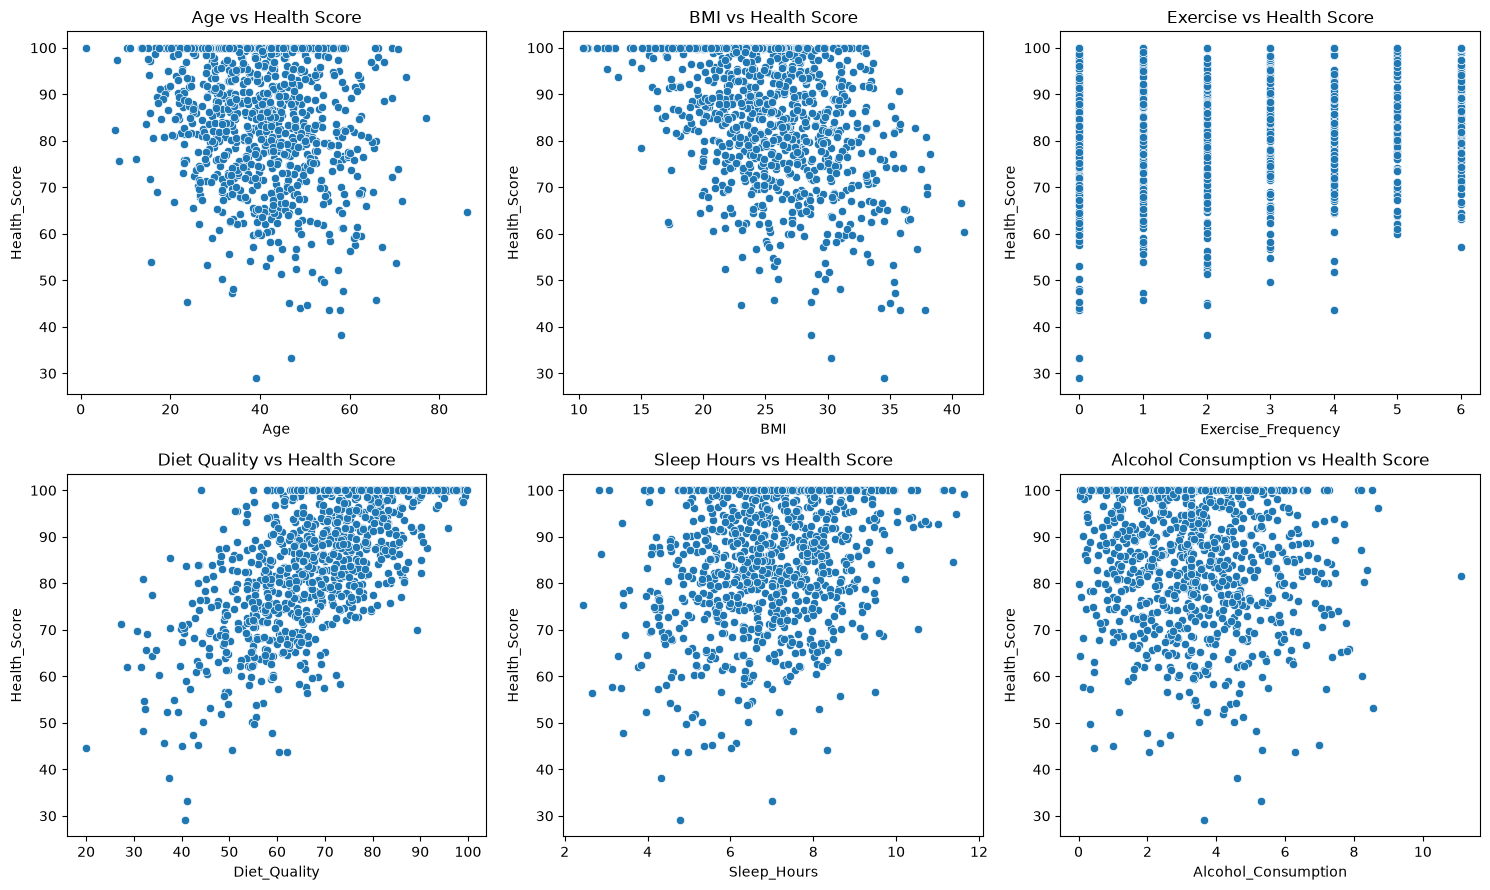

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

sns.scatterplot(data=df_clean, x="Age", y="Health_Score", ax=axes[0, 0])
axes[0, 0].set_title("Age vs Health Score")

sns.scatterplot(data=df_clean, x="BMI", y="Health_Score", ax=axes[0, 1])
axes[0, 1].set_title("BMI vs Health Score")

sns.scatterplot(data=df_clean, x="Exercise_Frequency", y="Health_Score", ax=axes[0, 2])
axes[0, 2].set_title("Exercise vs Health Score")

sns.scatterplot(data=df_clean, x="Diet_Quality", y="Health_Score", ax=axes[1, 0])
axes[1, 0].set_title("Diet Quality vs Health Score")

sns.scatterplot(data=df_clean, x="Sleep_Hours", y="Health_Score", ax=axes[1, 1])
axes[1, 1].set_title("Sleep Hours vs Health Score")

sns.scatterplot(data=df_clean, x="Alcohol_Consumption", y="Health_Score", ax=axes[1, 2])
axes[1, 2].set_title("Alcohol Consumption vs Health Score")

plt.tight_layout()
plt.show()

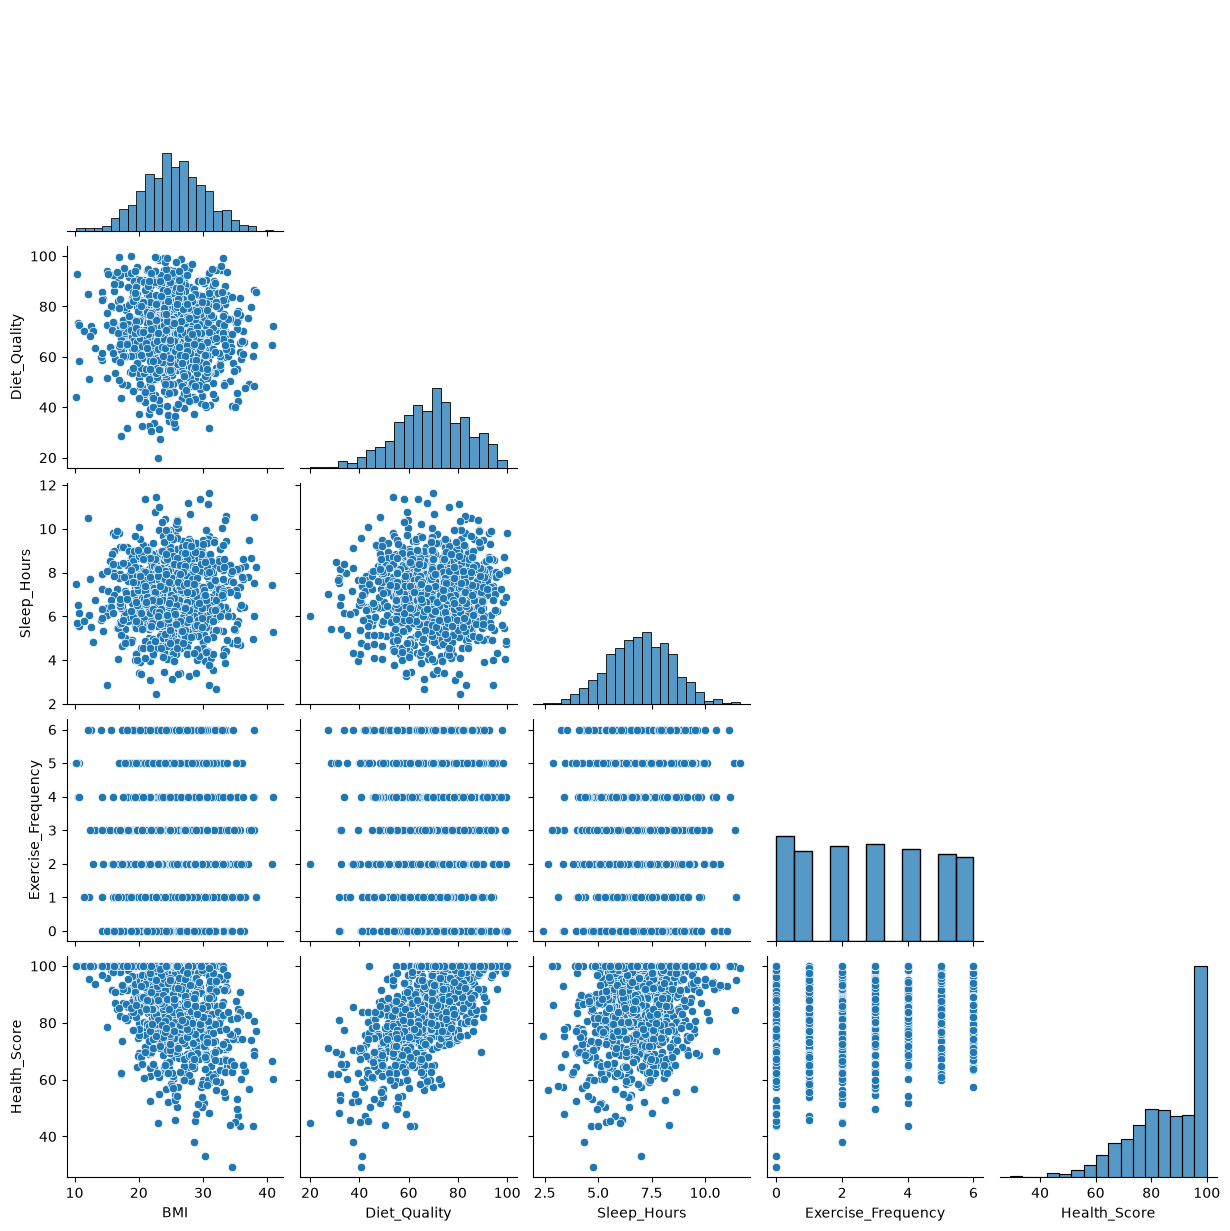

In [44]:
selected_features = [
    "BMI",
    "Diet_Quality",
    "Sleep_Hours",
    "Exercise_Frequency",
    "Health_Score"
]

sns.pairplot(
    df_clean[selected_features],
    corner=True
)

plt.show()

# Problem 1: Personalized Health-Score Prediction

## Objective

The goal of this problem is to predict an individual's continuous Health_Score using demographic and lifestyle variables.

The predictor variables are:

- Age
- BMI
- Exercise_Frequency
- Diet_Quality
- Sleep_Hours
- Smoking_Status
- Alcohol_Consumption

The target variable is:

- Health_Score

Several regression models will be trained and compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R-squared (R²), and cross-validation performance.

In [45]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_clean[
    [
        "Age",
        "BMI",
        "Exercise_Frequency",
        "Diet_Quality",
        "Sleep_Hours",
        "Smoking_Status",
        "Alcohol_Consumption"
    ]
]

y = df_clean["Health_Score"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


LINEAR REGRESSION

In [46]:
from sklearn.linear_model import LinearRegression

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print(f"MAE:  {mae_linear:.3f}")
print(f"RMSE: {rmse_linear:.3f}")
print(f"R²:   {r2_linear:.3f}")

MAE:  4.742
RMSE: 6.280
R²:   0.798


RIDGE REGRESSION

In [48]:
from sklearn.linear_model import Ridge

# Create and train Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE:  {mae_ridge:.3f}")
print(f"RMSE: {rmse_ridge:.3f}")
print(f"R²:   {r2_ridge:.3f}")

MAE:  4.741
RMSE: 6.279
R²:   0.798


LASSO REGRESSION

In [49]:
from sklearn.linear_model import Lasso

# Create and train Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

# Make predictions
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"MAE:  {mae_lasso:.3f}")
print(f"RMSE: {rmse_lasso:.3f}")
print(f"R²:   {r2_lasso:.3f}")

MAE:  4.717
RMSE: 6.238
R²:   0.800


NON-LINEAR MODELS

DECISION TREE REGRESSOR

In [50]:
from sklearn.tree import DecisionTreeRegressor

# Create and train Decision Tree
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree_model.predict(X_test)

# Evaluate
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print(f"MAE:  {mae_tree:.3f}")
print(f"RMSE: {rmse_tree:.3f}")
print(f"R²:   {r2_tree:.3f}")

MAE:  6.380
RMSE: 8.996
R²:   0.585


RANDOM FOREST REGRESSOR

In [51]:
from sklearn.ensemble import RandomForestRegressor

# Create and train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE:  {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R²:   {r2_rf:.3f}")

MAE:  4.183
RMSE: 5.774
R²:   0.829


GRADIENT BOOSTING REGRESSOR

In [52]:
from sklearn.ensemble import GradientBoostingRegressor

# Create and train Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"MAE:  {mae_gb:.3f}")
print(f"RMSE: {rmse_gb:.3f}")
print(f"R²:   {r2_gb:.3f}")

MAE:  4.088
RMSE: 5.503
R²:   0.845


XGBOOST

In [53]:
from xgboost import XGBRegressor

# Create and train XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MAE:  {mae_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"R²:   {r2_xgb:.3f}")

MAE:  4.003
RMSE: 5.387
R²:   0.851


NEURAL NETWORK

In [54]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create neural network pipeline
nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42,
        early_stopping=True
    ))
])

# Train
nn_model.fit(X_train, y_train)

# Predict
y_pred_nn = nn_model.predict(X_test)

# Evaluate
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print(f"MAE:  {mae_nn:.3f}")
print(f"RMSE: {rmse_nn:.3f}")
print(f"R²:   {r2_nn:.3f}")

MAE:  4.325
RMSE: 5.914
R²:   0.821


Cross validation performance

In [55]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.1),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        objective="reg:squarederror"
    ),

    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=42,
            early_stopping=True
        ))
    ])
}

In [56]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV RMSE"
)

print(cv_results_df.round(3).to_string(index=False))

            Model  CV MAE  CV RMSE  CV R²
   Neural Network   4.207    5.477  0.836
Gradient Boosting   4.364    5.667  0.826
          XGBoost   4.384    5.704  0.823
 Ridge Regression   4.518    5.884  0.810
Linear Regression   4.518    5.884  0.810
 Lasso Regression   4.524    5.888  0.810
    Random Forest   4.801    6.353  0.781
    Decision Tree   7.284    9.521  0.509


In [57]:
final_comparison = cv_results_df.copy()

final_comparison

,Model,CV MAE,CV RMSE,CV R²
7,Neural Network,4.206505,5.476819,0.836188
5,Gradient Boosting,4.363513,5.667115,0.825869
6,XGBoost,4.383666,5.703870,0.823392
1,Ridge Regression,4.517666,5.883884,0.810274
0,Linear Regression,4.517521,5.883901,0.810272
2,Lasso Regression,4.523598,5.888149,0.810055
4,Random Forest,4.801091,6.353007,0.780824
3,Decision Tree,7.283575,9.521382,0.508522


Tuning the top 3 models

GRADIENT BOOSTING REGRESSOR

In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

param_grid_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best parameters:")
print(grid_gb.best_params_)

print("\nBest CV RMSE:")
print(-grid_gb.best_score_)

Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Best CV RMSE:
5.602999600729019


In [59]:
# Get the best Gradient Boosting model
best_gb_model = grid_gb.best_estimator_

# Make predictions on the test set
y_pred_gb_tuned = best_gb_model.predict(X_test)

# Calculate test metrics
mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)

print(f"Test MAE:  {mae_gb_tuned:.3f}")
print(f"Test RMSE: {rmse_gb_tuned:.3f}")
print(f"Test R²:   {r2_gb_tuned:.3f}")

Test MAE:  3.952
Test RMSE: 5.254
Test R²:   0.858


XGBOOST

In [60]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best parameters:")
print(grid_xgb.best_params_)

print("\nBest CV RMSE:")
print(-grid_xgb.best_score_)

Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}

Best CV RMSE:
5.343393808316362


In [61]:
# Get the best XGBoost model
best_xgb_model = grid_xgb.best_estimator_

# Make predictions on the test set
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Calculate test metrics
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print(f"Test MAE:  {mae_xgb_tuned:.3f}")
print(f"Test RMSE: {rmse_xgb_tuned:.3f}")
print(f"Test R²:   {r2_xgb_tuned:.3f}")

Test MAE:  4.014
Test RMSE: 5.284
Test R²:   0.857


NEURAL NETWORK

In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

nn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        random_state=42
    ))
])

param_grid_nn = {
    "model__hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32),
        (128, 64),
        (128, 64, 32)
    ],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01]
}

grid_nn = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=param_grid_nn,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_nn.fit(X_train, y_train)

print("Best parameters:")
print(grid_nn.best_params_)

print("\nBest CV RMSE:")
print(-grid_nn.best_score_)

Best parameters:
{'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64, 32), 'model__learning_rate_init': 0.01}

Best CV RMSE:
5.353900188322795


In [63]:
# Get the best Neural Network model
best_nn_model = grid_nn.best_estimator_

# Make predictions on the test set
y_pred_nn_tuned = best_nn_model.predict(X_test)

# Calculate test metrics
mae_nn_tuned = mean_absolute_error(y_test, y_pred_nn_tuned)
rmse_nn_tuned = np.sqrt(mean_squared_error(y_test, y_pred_nn_tuned))
r2_nn_tuned = r2_score(y_test, y_pred_nn_tuned)

print(f"Test MAE:  {mae_nn_tuned:.3f}")
print(f"Test RMSE: {rmse_nn_tuned:.3f}")
print(f"Test R²:   {r2_nn_tuned:.3f}")

Test MAE:  3.903
Test RMSE: 5.405
Test R²:   0.850


Feature importance

In [64]:
# Get feature importance from the tuned Gradient Boosting model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_gb_model.feature_importances_
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
3         Diet_Quality    0.506231
1                  BMI    0.215084
4          Sleep_Hours    0.095345
2   Exercise_Frequency    0.086588
0                  Age    0.049023
6  Alcohol_Consumption    0.031452
5       Smoking_Status    0.016276


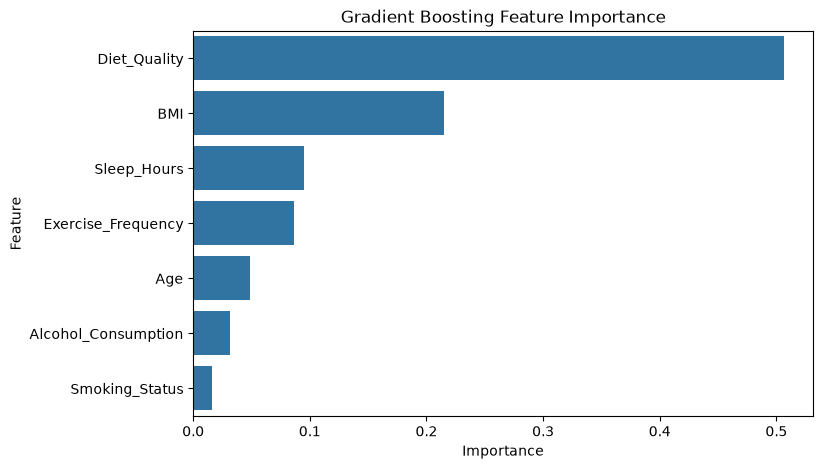

In [65]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Permutation importance

In [66]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set
perm_importance = permutation_importance(
    best_gb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

permutation_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
})

permutation_df = permutation_df.sort_values(
    by="Importance",
    ascending=False
)

print(permutation_df)

               Feature  Importance
3         Diet_Quality    9.457020
1                  BMI    4.346170
2   Exercise_Frequency    2.199913
4          Sleep_Hours    2.123634
0                  Age    1.395414
5       Smoking_Status    0.464815
6  Alcohol_Consumption    0.131750


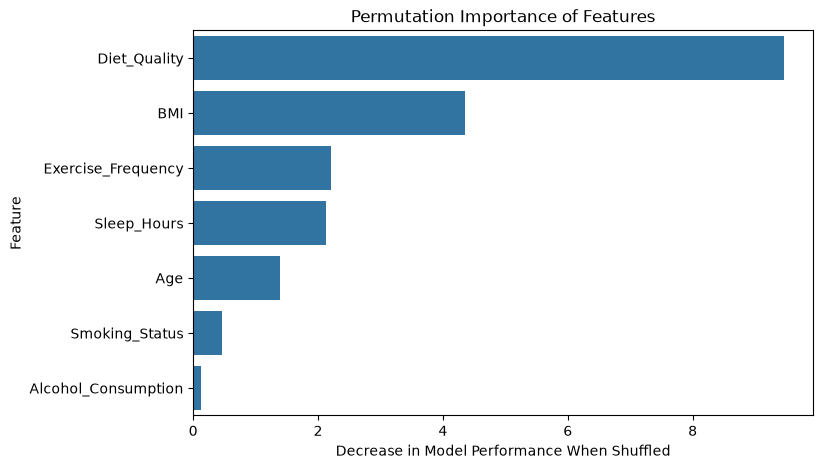

In [67]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=permutation_df,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Importance of Features")
plt.xlabel("Decrease in Model Performance When Shuffled")
plt.ylabel("Feature")
plt.show()

Investigating how health score is calculated

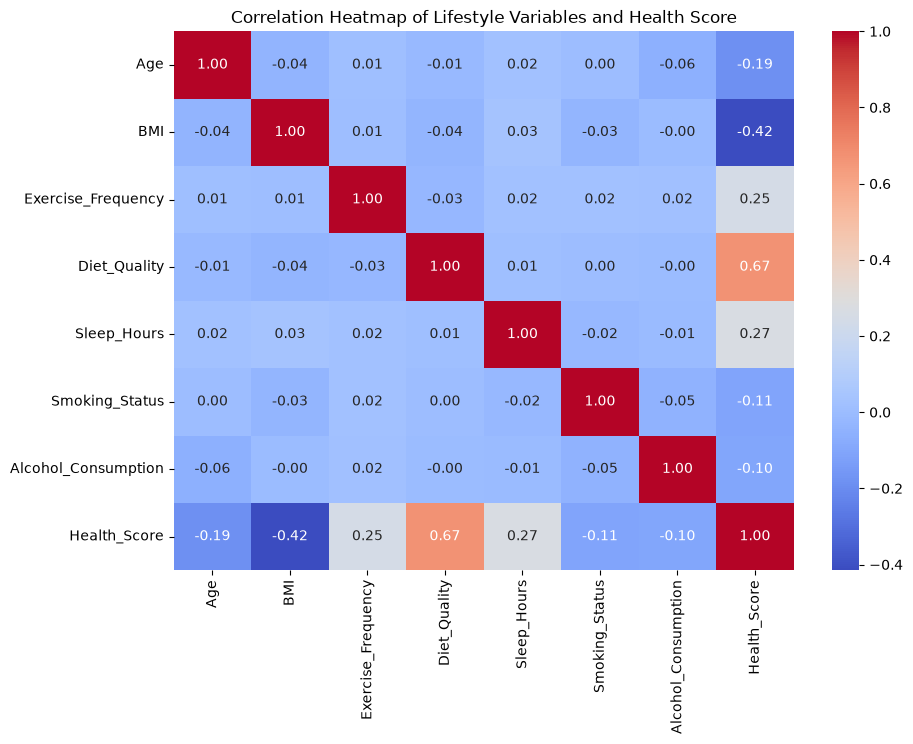

In [68]:
correlation_matrix = df_clean[
    [
        "Age",
        "BMI",
        "Exercise_Frequency",
        "Diet_Quality",
        "Sleep_Hours",
        "Smoking_Status",
        "Alcohol_Consumption",
        "Health_Score"
    ]
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Lifestyle Variables and Health Score")
plt.show()

Can a linear calculation reproduce health score? If MAE is 0 and R² is 1, health score is a mathematical function of the 7 variables

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features used to calculate/predict Health Score
features = [
    "Age",
    "BMI",
    "Exercise_Frequency",
    "Diet_Quality",
    "Sleep_Hours",
    "Smoking_Status",
    "Alcohol_Consumption"
]

X_leakage = df_clean[features]
y_leakage = df_clean["Health_Score"]

# Fit a linear model using the entire dataset
leakage_model = LinearRegression()
leakage_model.fit(X_leakage, y_leakage)

# Predict Health Score
health_score_pred = leakage_model.predict(X_leakage)

# Evaluate how closely the variables reproduce Health Score
leakage_mae = mean_absolute_error(y_leakage, health_score_pred)
leakage_r2 = r2_score(y_leakage, health_score_pred)

print(f"MAE: {leakage_mae:.4f}")
print(f"R²:  {leakage_r2:.4f}")

print("\nCoefficients:")
for feature, coefficient in zip(features, leakage_model.coef_):
    print(f"{feature}: {coefficient:.4f}")

print(f"\nIntercept: {leakage_model.intercept_:.4f}")

MAE: 4.4736
R²:  0.8162

Coefficients:
Age: -0.2455
BMI: -1.1326
Exercise_Frequency: 1.8317
Diet_Quality: 0.6281
Sleep_Hours: 2.4198
Smoking_Status: -3.6170
Alcohol_Consumption: -0.9438

Intercept: 63.3425
